# Loading theory data
This notebook contains test scripts to load theory data. Final figures will still be in the main figure notebook.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import h5py
from matplotlib import colors


import sys
sys.path.append("../utils")
from utils import *

from utils import update_rc_params
update_rc_params('talk')

# LL plot

In [6]:
def plot_theory_LL(fig, ax, norm, cmap, u_index):
    with h5py.File("../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5", "r") as f:
        uD_meV         = f["uD_meV"][:]
        Bs_arr         = f["Bs_T"][:]
        ns_lin         = f["ns_lin"][:]
        # h5py reverses axes vs Julia column-major:
        #   rhos     written  (n_D, Nns, Nfluxes)        → read (Nfluxes, Nns, n_D)
        #   ns_lines written  (n_D, N_lines, Nfluxes)    → read (Nfluxes, N_lines, n_D)
        rhos           = f["rhos"][:].T              # → (n_D, Nns, Nfluxes)
        ns_lines       = f["ns_lines"][:].T          # → (n_D, N_lines, Nfluxes)
        n_lines_per_D  = f["n_lines_per_D"][:]
        valley         = int(f["valley"][()])
        Nll            = int(f["Nll"][()])

    n_D = len(uD_meV)
    xs = ns_lin[1:] # to avoid zero density
    ys = Bs_arr
    zs = rhos[u_index, 1:, :].T  # to avoid zero density

    plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
    ax.set_xlabel(r"$n\;(10^{12}\,\mathrm{cm}^{-2})$")
    ax.set_ylabel(r"$B$ (T)")

    return plot

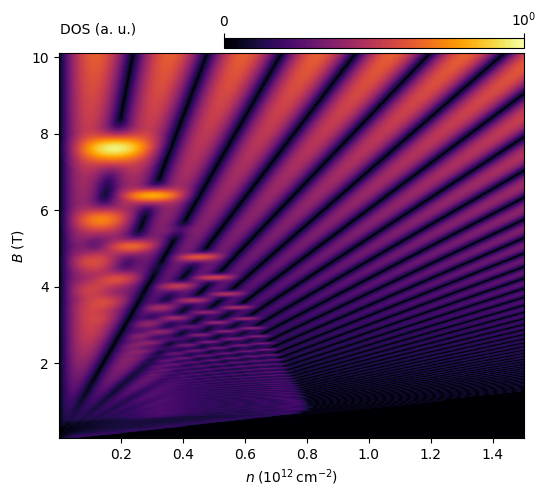

In [7]:
fig = plt.figure(figsize=(6,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=0, vmax=1)
plot = plot_theory_LL(fig, ax, norm, "inferno", u_index=3)

pos = ax.get_position()
cb_width = 0.5
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[0,1], \
                  orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'DOS (a. u.)', labelpad=-17, x=-0.42)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')   

# QO plots

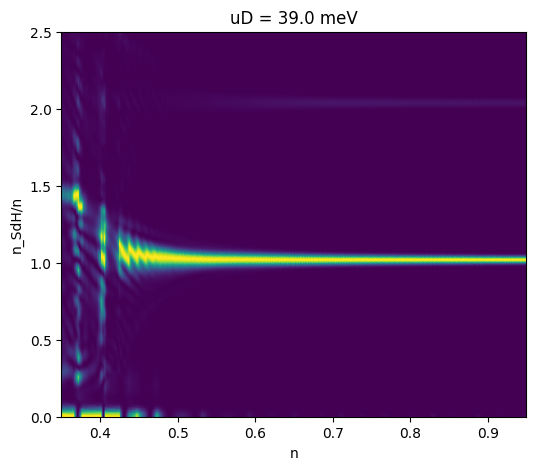

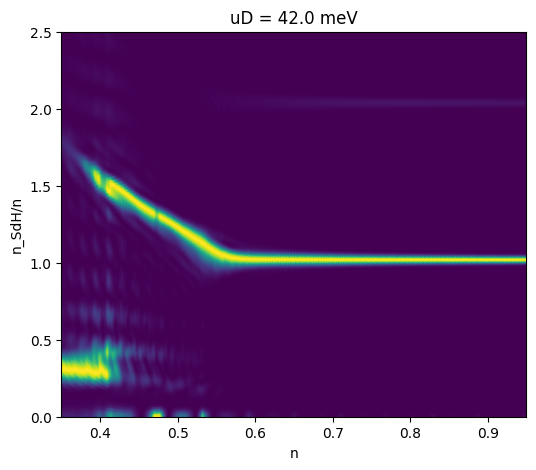

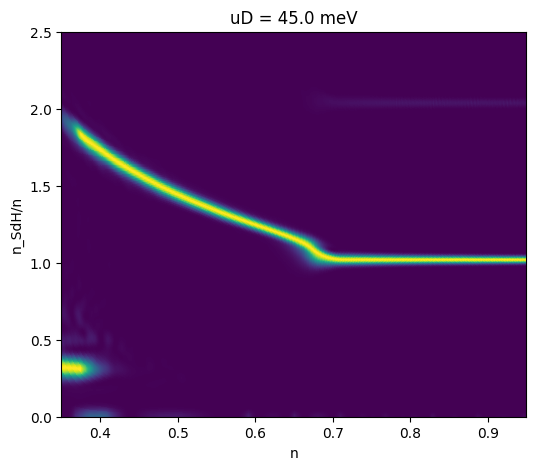

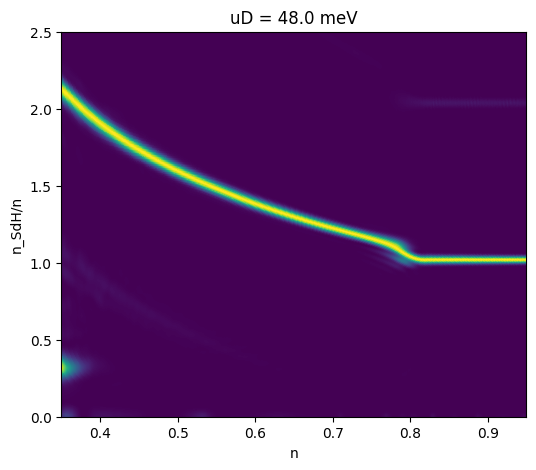

In [14]:
for u_index in range(4):
    with h5py.File("../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5", "r") as f:
        uD_meV         = f["uD_meV"][:]
        Bs_arr         = f["Bs_T"][:]
        ns_lin         = f["ns_lin"][:]
        # h5py reverses axes vs Julia column-major:
        #   rhos     written  (n_D, Nns, Nfluxes)        → read (Nfluxes, Nns, n_D)
        #   ns_lines written  (n_D, N_lines, Nfluxes)    → read (Nfluxes, N_lines, n_D)
        rhos           = f["rhos"][:].T              # → (n_D, Nns, Nfluxes)
        ns_lines       = f["ns_lines"][:].T          # → (n_D, N_lines, Nfluxes)
        n_lines_per_D  = f["n_lines_per_D"][:]
        valley         = int(f["valley"][()])
        Nll            = int(f["Nll"][()])
    
    n_D = len(uD_meV)
    xs = ns_lin[1:] # to avoid zero density
    ys = Bs_arr
    zs = rhos[u_index, 1:, :].T  # to avoid zero density

    blo = 0.7
    bhi = 2.5
    
    indlo = np.abs(ys-blo).argmin()
    indhi = np.abs(ys-bhi).argmin()
    ys = ys[indlo:indhi]
    zs = zs[indlo:indhi]    
    
    padding = 5
    psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=4.5, order=3, padding=padding, normalize=True)
    xs_repeated = np.tile(xs, (freqs.shape[0], 1))

    #blo = 0.9
    #bhi = 5
    #indlo = np.abs(ys-blo).argmin()
    #indhi = np.abs(ys-bhi).argmin()
    #if indlo < indhi:
    #    ys = ys[indlo:indhi]
    #    zs = zs[indlo:indhi]   
    #else:
    #    ys = ys[indhi:indlo]
    #    zs = zs[indhi:indlo]  
    #win = 101
    #padding = 5
    
    #psds, freqs = make_mat_fft(ys, zs, xs, nx=500, win=win, padding=padding, poly=3, max_win_frac=0.4)
    
    #xs_repeated = np.tile(xs, (freqs.shape[0], 1))
    unnorm_freqs = np.array([f*xs for f in freqs])
    
    fig = plt.figure(figsize=(6,5))
    ax = plt.gca()
    norm = colors.SymLogNorm(linthresh=1, vmin=0, vmax=1)
    cmap = "viridis"
    plot = ax.pcolormesh(xs_repeated, freqs, psds, norm=norm, cmap=cmap, rasterized=True, lw=0)
    ax.set_xlim(0.35, 0.95) 
    ax.set_ylim(0, 2.5)
    ax.set_title("uD = " + str(uD_meV[u_index]) + " meV")
    ax.set_xlabel("n")
    ax.set_ylabel("n_SdH/n")
plt.tight_layout()

In [12]:
uD_meV[u_index]

np.float64(39.0)

In [15]:
def plot_theory_fft(fig, ax, norm, cmap="viridis", u_index = 3):
    with h5py.File("../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5", "r") as f:
        uD_meV         = f["uD_meV"][:]
        Bs_arr         = f["Bs_T"][:]
        ns_lin         = f["ns_lin"][:]
        # h5py reverses axes vs Julia column-major:
        #   rhos     written  (n_D, Nns, Nfluxes)        → read (Nfluxes, Nns, n_D)
        #   ns_lines written  (n_D, N_lines, Nfluxes)    → read (Nfluxes, N_lines, n_D)
        rhos           = f["rhos"][:].T              # → (n_D, Nns, Nfluxes)
        ns_lines       = f["ns_lines"][:].T          # → (n_D, N_lines, Nfluxes)
        n_lines_per_D  = f["n_lines_per_D"][:]
        valley         = int(f["valley"][()])
        Nll            = int(f["Nll"][()])
    
    n_D = len(uD_meV)
    xs = ns_lin[1:] # to avoid zero density
    ys = Bs_arr
    zs = rhos[u_index, 1:, :].T  # to avoid zero density
    blo = 0.7
    bhi = 2.5
    
    indlo = np.abs(ys-blo).argmin()
    indhi = np.abs(ys-bhi).argmin()
    ys = ys[indlo:indhi]
    zs = zs[indlo:indhi]    
    
    padding = 5
    psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=4.5, order=3, padding=padding, normalize=True)
    xs_repeated = np.tile(xs, (freqs.shape[0], 1))
    
    unnorm_freqs = np.array([f*xs for f in freqs])
    plot = ax.pcolormesh(xs_repeated, unnorm_freqs, psds, norm=norm, cmap=cmap, rasterized=True, lw=0)
    ax.set_xlim(0.35, 0.95) 
    ax.set_ylim(0, 1.5)

    return plot
   

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_12252/4237076745.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(xs_repeated, unnorm_freqs, psds, norm=norm, cmap=cmap, rasterized=True, lw=0)


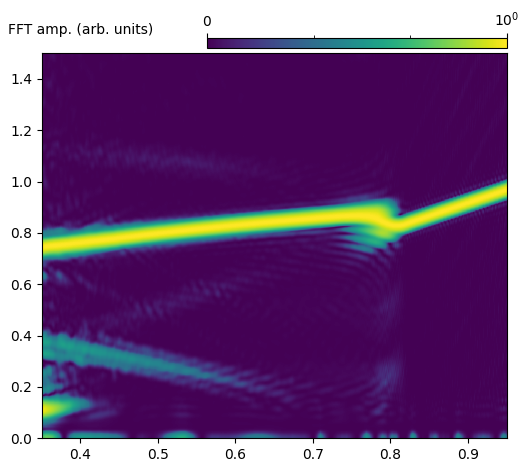

In [20]:
fig = plt.figure(figsize=(6,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=0.01, vmin=0, vmax=1)
plot = plot_theory_fft(fig, ax, norm, "viridis", u_index=3)

pos = ax.get_position()
cb_width = 0.5
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[0,1], \
                  orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'FFT amp. (arb. units)', labelpad=-17, x=-0.42)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')   